# Lab 3
# Linear Regression


# <span style="color:red;">➡Data	Collection:</span> 

# Step 1: Import required libraries

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Step 2: Load the Dataset into Jupyter Notebook

In [2]:
# https://www.kaggle.com/datasets/ashydv/advertising-dataset
df = pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


#  <span style="color:red;">➡Data Exploration:</span>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.shape

(200, 4)

In [8]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


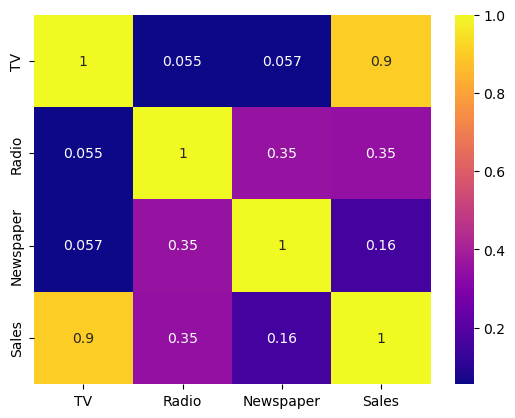

In [9]:
sns.heatmap(df.corr(),annot=True,cmap='plasma')
plt.show()

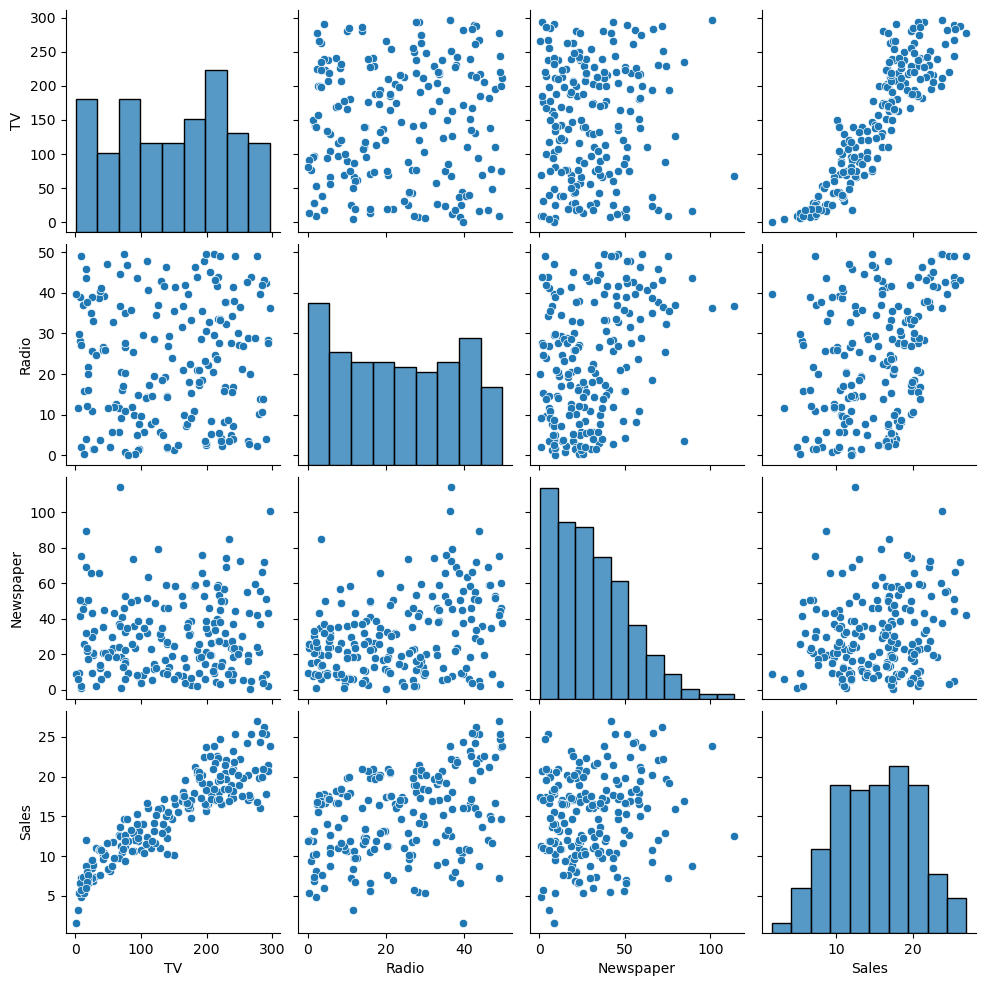

In [10]:
sns.pairplot(df)
plt.show()

# <span style="color:red;">➡Data preprocessing</span> (data preparation and Cleaning)
## Handle	missing	values	and	duplicates,	remove	or	replace	outliers

# Step 1:Missing Values Handling:

In [11]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

# Step 2: Duplicate Handling.

In [12]:
df.duplicated().sum()

np.int64(0)

# Step 3: Outliers Handling

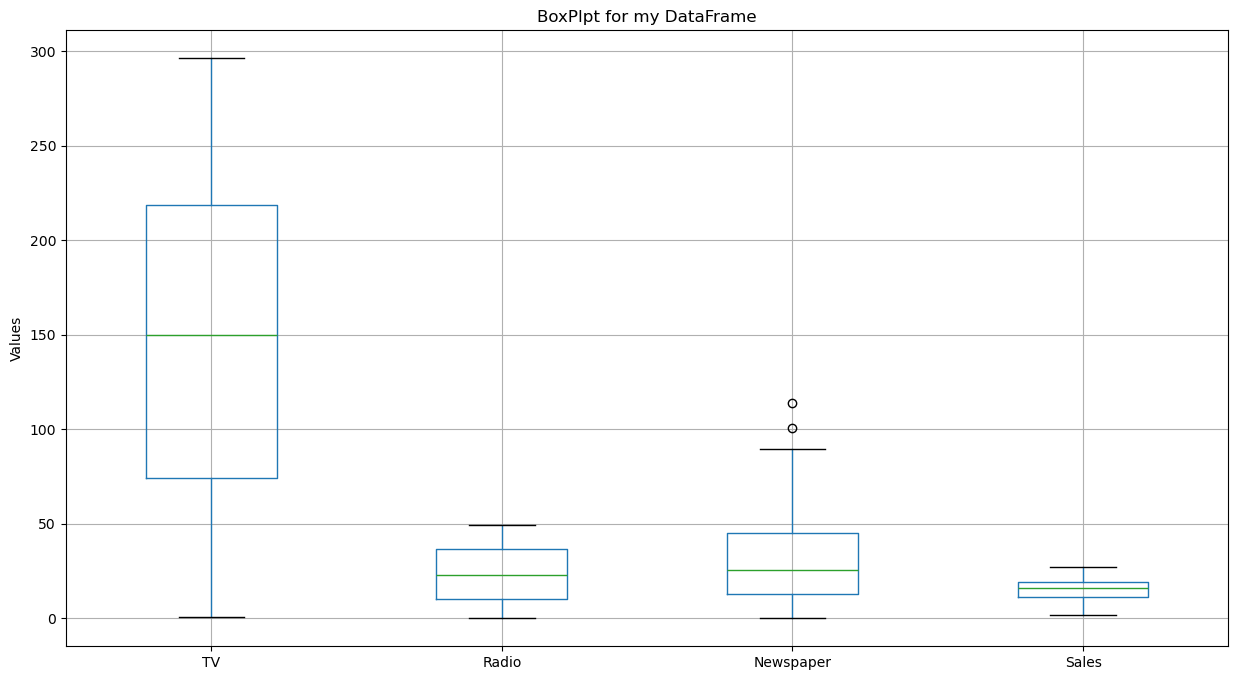

In [13]:
num_colmuns=df.select_dtypes(include=["float64","int64","int32"]).columns

plt.figure(figsize=(15,8))
df[num_colmuns].boxplot()
plt.title("BoxPlpt for my DataFrame")
plt.ylabel("Values")
plt.grid(True)
plt.show()

In [14]:
# Calculate Q1 and Q3 for each column (except the 'Sales' column):
num_columns2 = num_colmuns.drop('Sales')

Q1 = df[num_columns2].quantile(0.25)
Q3 = df[num_columns2].quantile(0.75)

#Calculate IQR (difference between Q3  and Q1):
IQR = Q3 - Q1

## Identify outliers based on IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows that contain values outside the range
clean_df = df[~((df[num_columns2] < lower_bound) | (df[num_columns2] > upper_bound)).any(axis=1)]
#clean_df = df[((df[num_columns2] > lower_bound) | (df[num_columns2] < upper_bound)).any(axis=1)]



In [15]:
# Print the statistics after deletion
print(f"Number of original values: {len(df)}")
print(f"Number of values after deleting outliers: {len(clean_df)}")

Number of original values: 200
Number of values after deleting outliers: 198


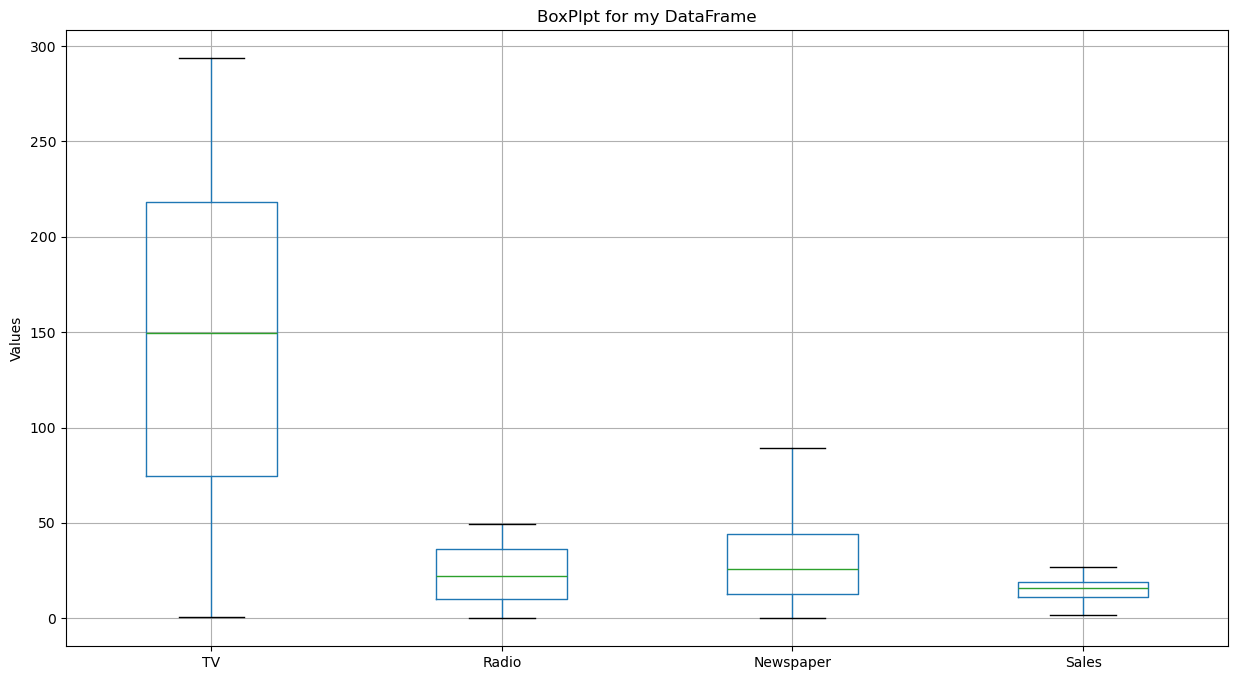

In [16]:
num_colmuns=clean_df.select_dtypes(include=["float64","int64","int32"]).columns

plt.figure(figsize=(15,8))
clean_df[num_colmuns].boxplot()
plt.title("BoxPlpt for my DataFrame")
plt.ylabel("Values")
plt.grid(True)
plt.show()

# <span style="color:red;">➡Linear Regression Model</span>

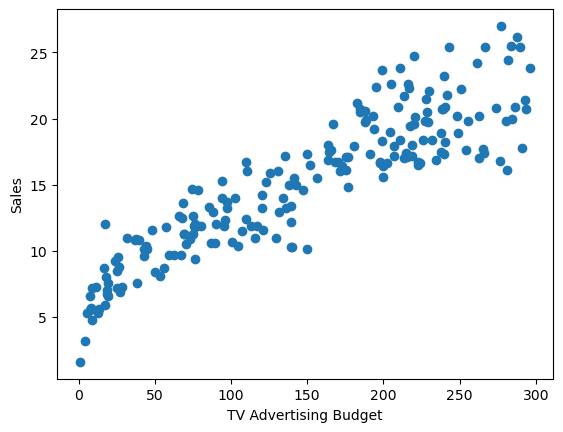

In [20]:
x = df['TV']
y = df['Sales']

plt.plot(x, y, 'o')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


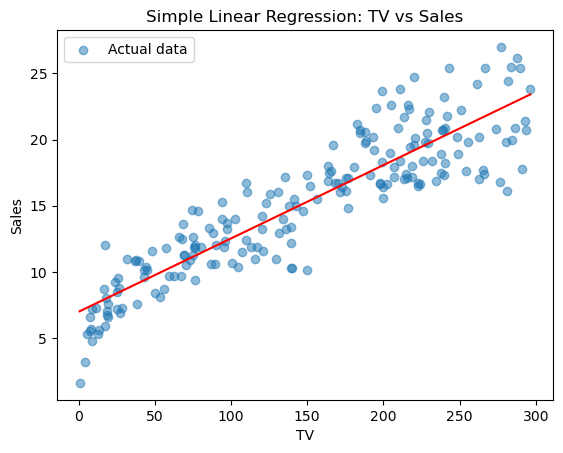

In [34]:
X_tv = df[['TV']]
y = df['Sales']

model.fit(X_tv, y)

import numpy as np
tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 100).reshape(-1, 1)

y_plot = model.predict(tv_range)

import matplotlib.pyplot as plt
plt.scatter(df['TV'], df['Sales'], alpha=0.5, label='Actual data')
plt.plot(tv_range, y_plot, 'r-')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Simple Linear Regression: TV vs Sales')
plt.legend()
plt.show()


## 1) Define input features (X) and target variable (y)

In [22]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

## 2) Split the data into training and testing sets

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3) Create and train the Linear Regression model

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) # معادلة خطية

LinearRegression()

## 4) Predict values using the test data

In [24]:
y_pred = model.predict(X_test)

## 5) Evaluate model performance

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 :", r2)

MSE: 2.9077569102710923
R2 : 0.9059011844150826
